In [ ]:
!pip install numpy
!pip install pandas
!pip install matplotlib
!pip install seaborn
!pip install scikit-learn


In [ ]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.metrics import r2_score


In [ ]:
path="C:\\Users\\CANSU\\Desktop\\ML\\NASA TURBOFAN DATASET\\train_FD001.txt"
df=pd.read_csv(path,sep=" ")

In [ ]:
df.head()


In [ ]:
df.shape

In [ ]:
df.columns

In [ ]:
df.drop(['Unnamed: 27','Unnamed: 26'],axis=1,inplace=True) # I am dropping features that has just NaN value

In [ ]:
df.columns

In [ ]:
columns_name=["unit_number","time_in_cycles","os_1","os_2","os_3"]
for i in range(1,22):
    columns_name.append(f"s_{i}")
columns_name

In [ ]:
df.columns=columns_name
df.head()

In [ ]:
df.isna().sum()

In [ ]:
for col in df.columns:
    print(df[col].value_counts())


In [ ]:
df.drop(["os_3","s_1","s_5","s_10","s_16","s_18","s_19"],axis=1,inplace=True)#(Constant Features):These features have only one value.For this reason I dropped them. Because there aren't information gain for any ML models. Their variance is zero.

In [ ]:
df.shape

In [ ]:
corr_df=df.drop(["time_in_cycles","unit_number"],axis=1).corr()
corr_df

In [ ]:
#multicollinearity

for i in corr_df:
    for j in corr_df:
         if 0.85<corr_df[i][j]<1: #This means: %85 and more similar features.High Correlated
            print(i,j,corr_df[i][j]) # Sensor_9 and Sensor_14 indicate almost the same thing.
                                     # For this reason, I remove one of them



In [ ]:
df.drop(["s_14"],axis=1,inplace=True)

In [ ]:
sns.barplot()

In [ ]:
failure_cycles=df.groupby(by="unit_number").describe()["time_in_cycles"]["count"]#Failure cycles of the machines
failure_cycles.idxmax()

In [ ]:
sns.barplot(failure_cycles)
plt.show()

In [ ]:
failure_cycles.min()# this train data has minimum 128 cycles after broken machines.
failure_cycles.median()#This means that machines generally fail around 199 cycles.
failure_cycles.max()#This machines more durable than other machines


# Okay, let's continue with 3 machines to understand the data better.
* Machine 1 -> Machine to first failure, the has minimum cycle (128 cycle)
* Machine 2 -> This machine has an median cycle.(199 cycle)
* Machine 3 -> This machine, that actually we don't know its conditions, much quality machine from the dataset.(362 cycle)

In [ ]:
failure_cycles

In [ ]:
df["unit_number"].value_counts() #The value_counts() function in pandas returns a sorted object by default. So last element of this list is "durable machine".

In [ ]:
machine_1_df=df.loc[df["unit_number"]==failure_cycles.idxmax()]
machine_1_df

In [ ]:
machine_2_df = df.loc[df["unit_number"]==failure_cycles.sort_values().index[50]]
machine_2_df

In [ ]:
machine_3_df = df.loc[df["unit_number"]==failure_cycles.idxmin()]
machine_3_df

In [ ]:
machine_2_df.describe().loc[["min","max","mean","std"]]

In [ ]:
machine_1_df.describe().loc[["min","max","mean","std"]]

In [ ]:
machine_3_df.describe().loc[["min","max","mean","std"]]

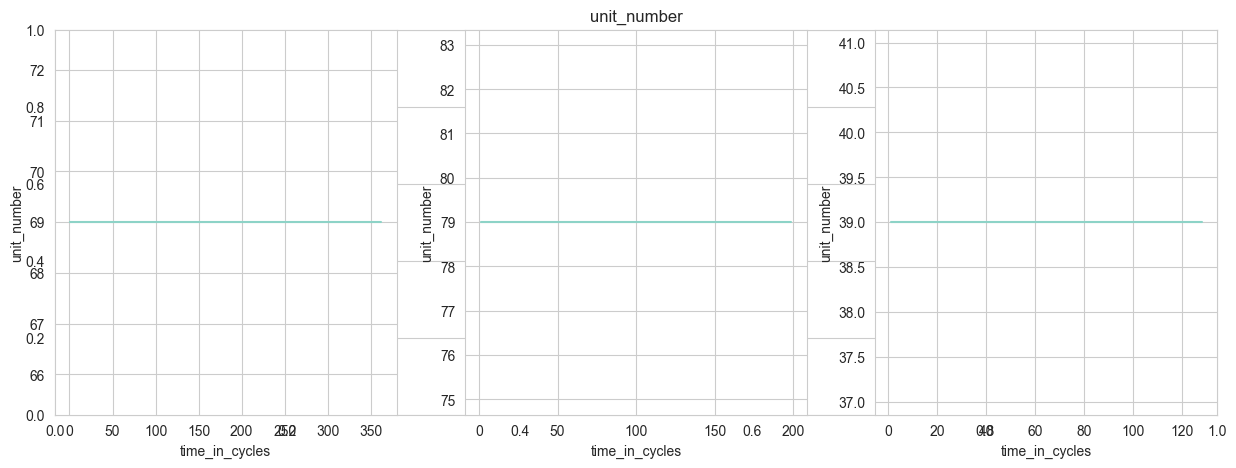

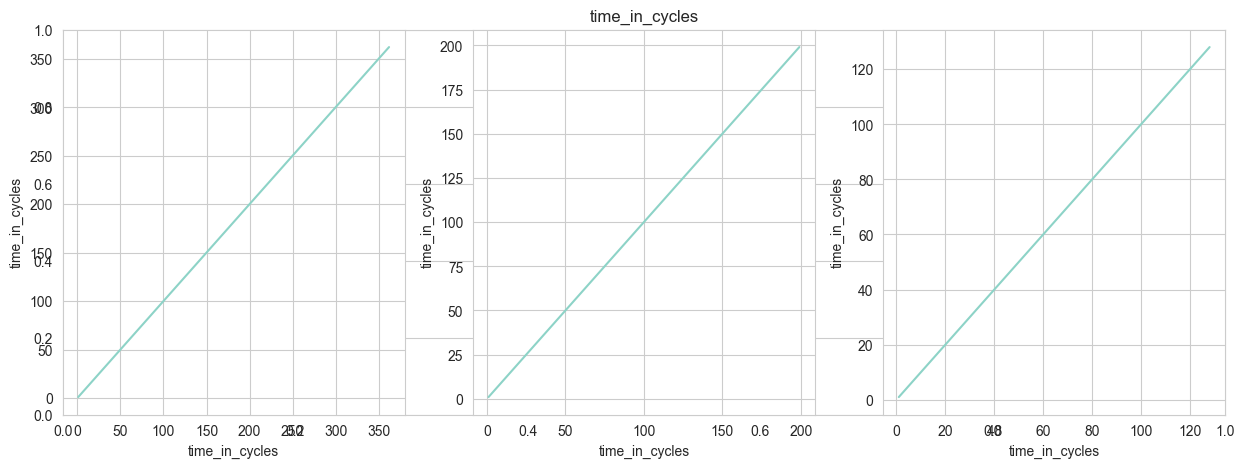

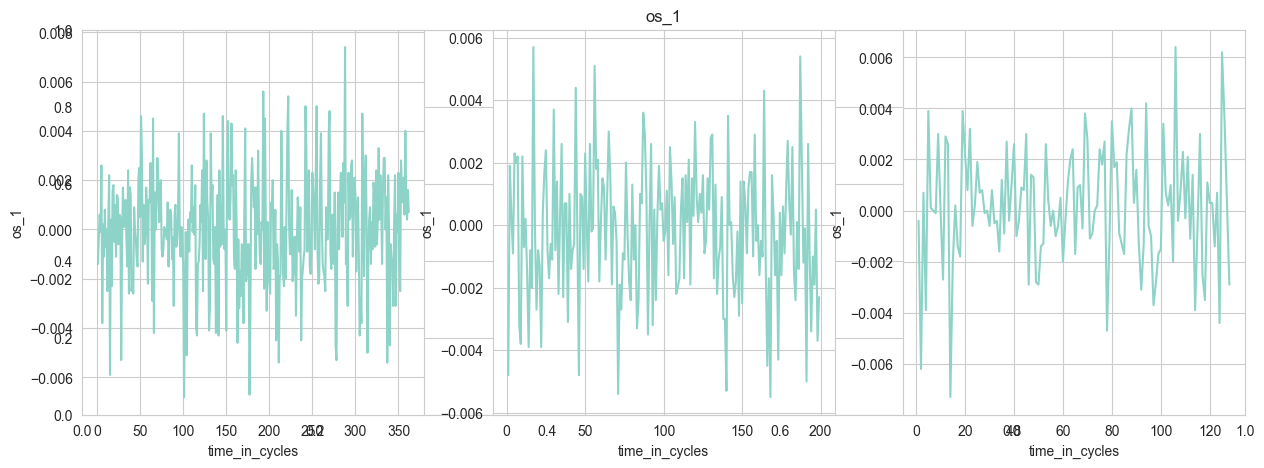

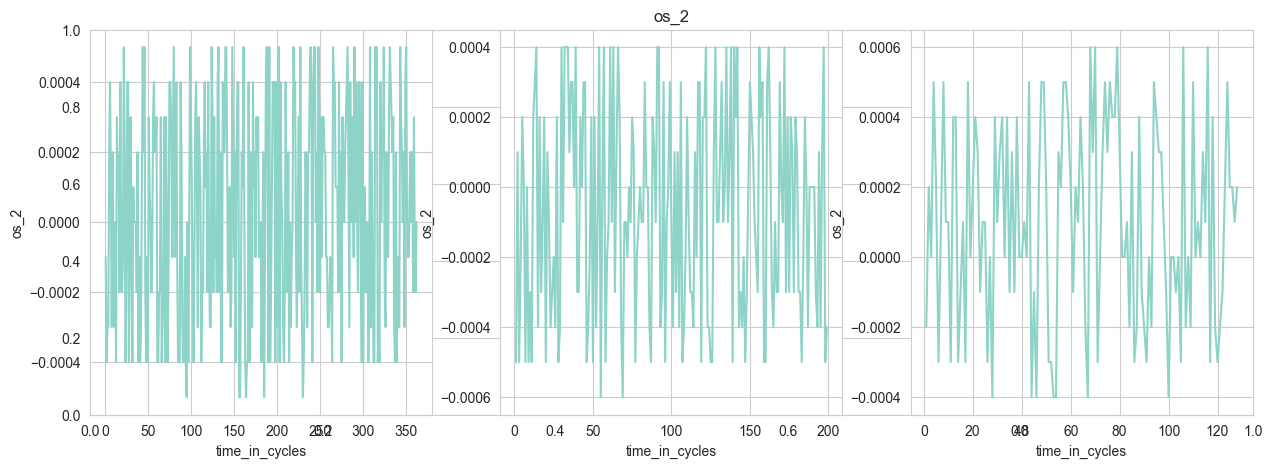

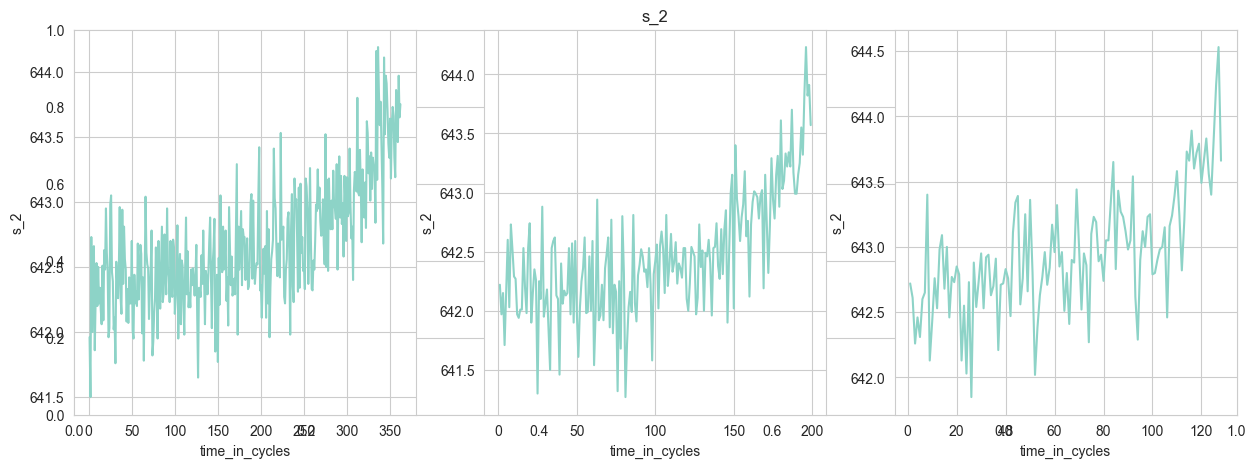

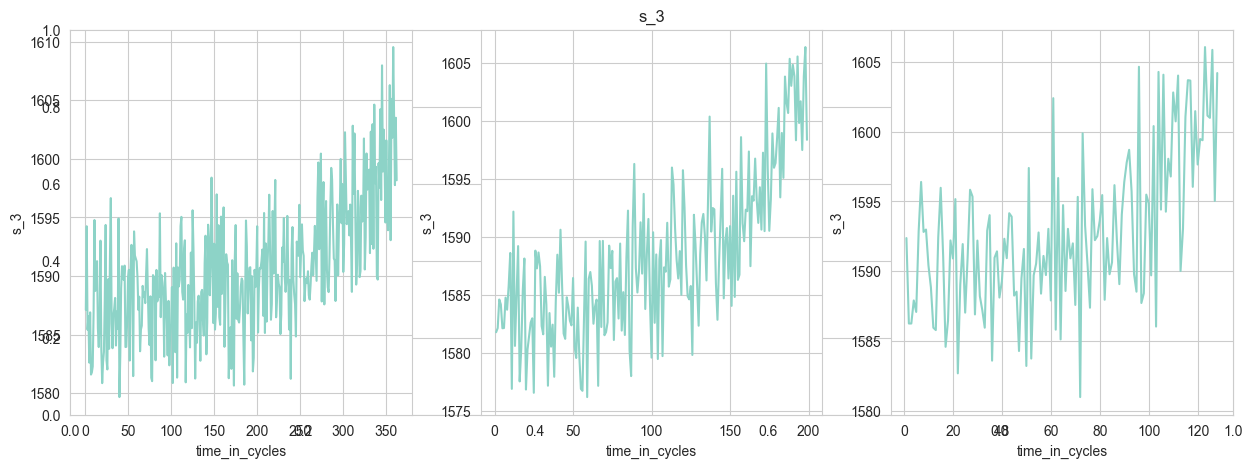

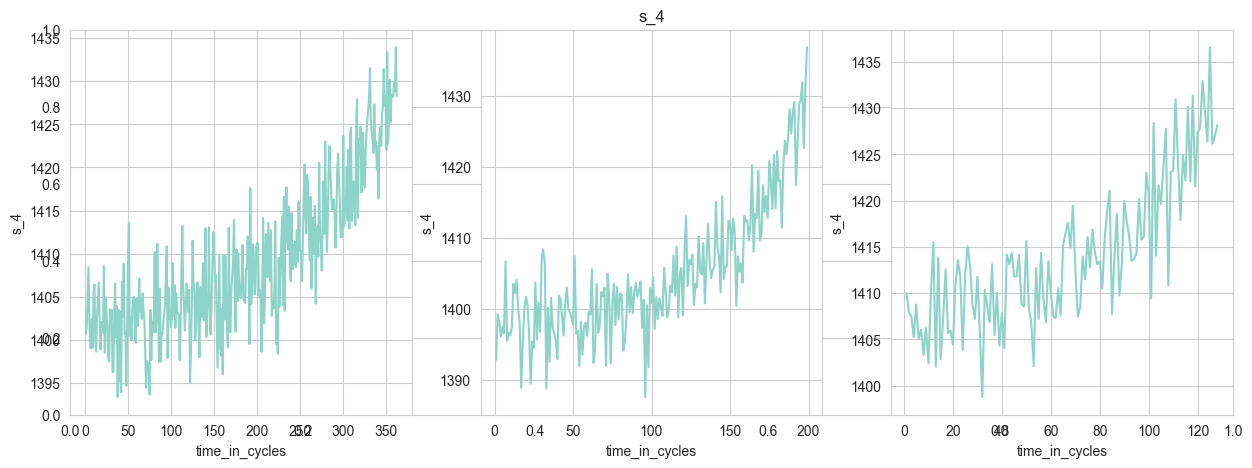

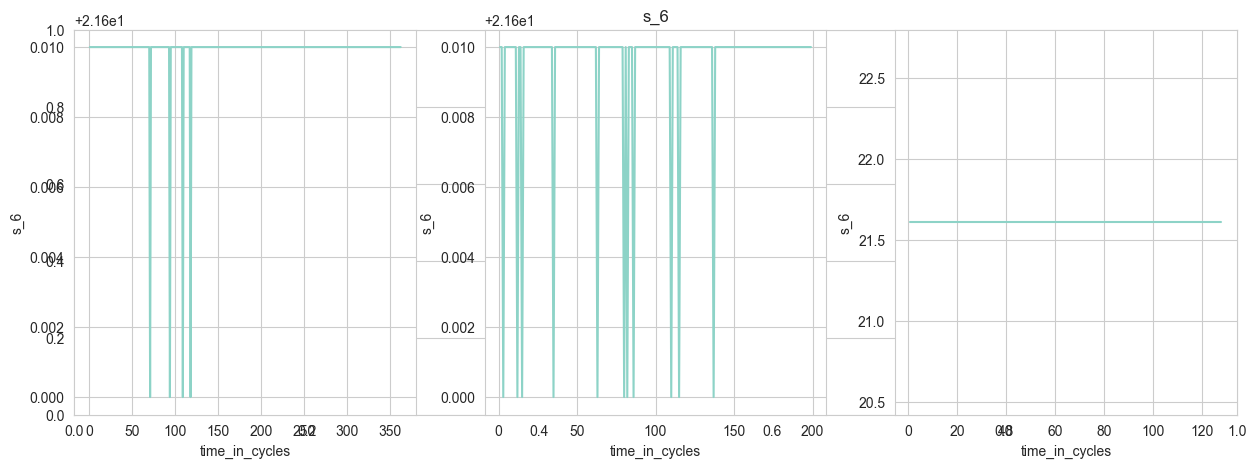

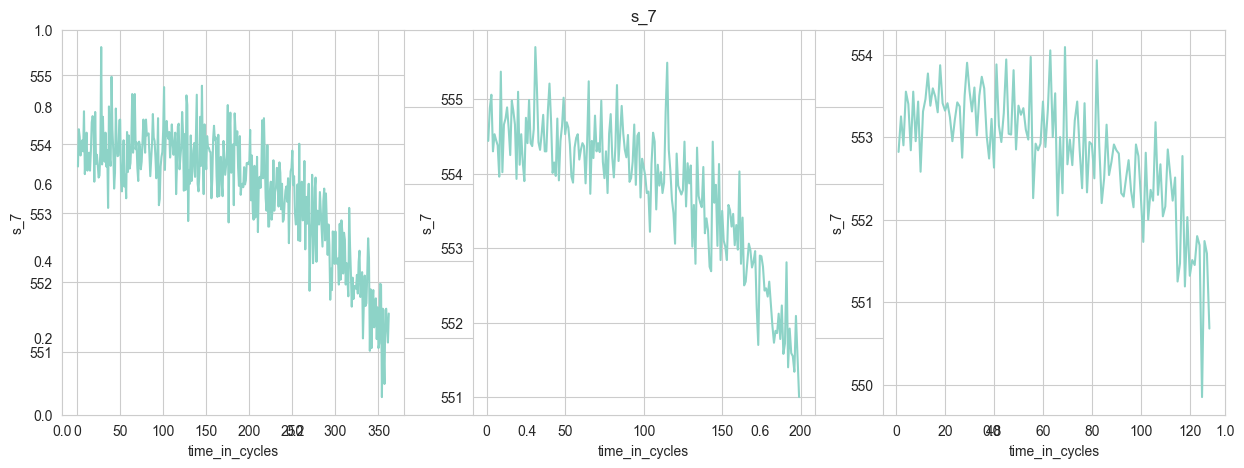

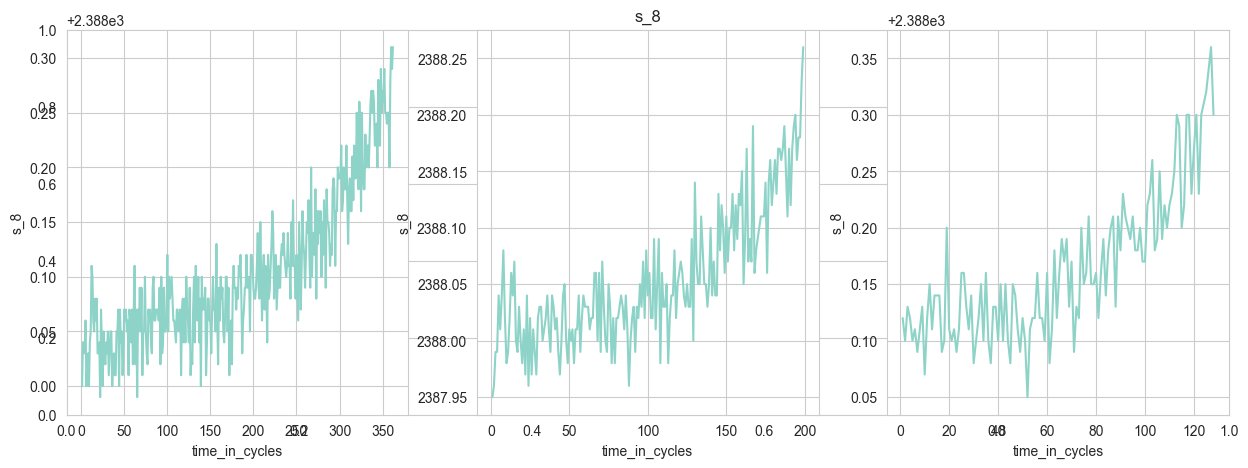

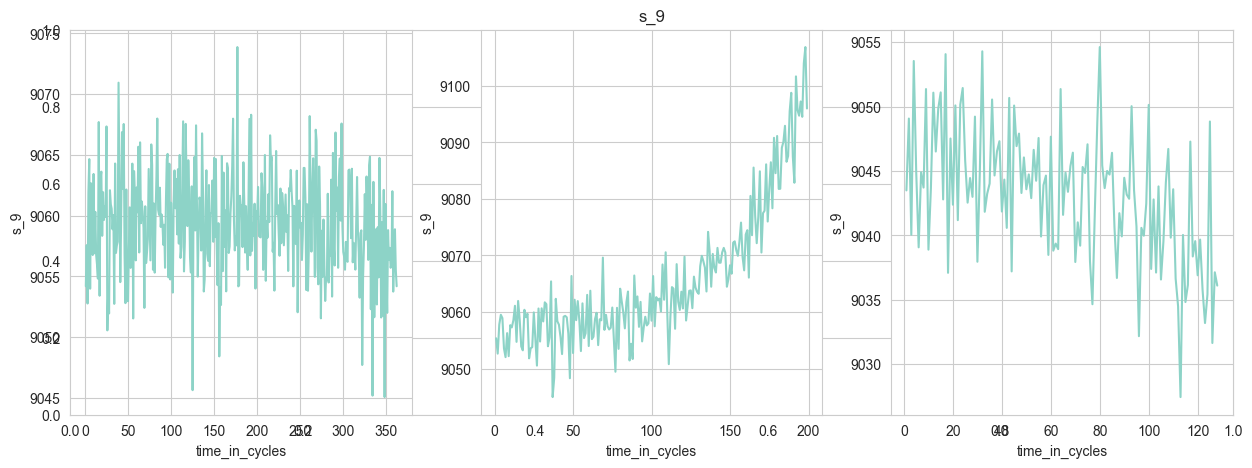

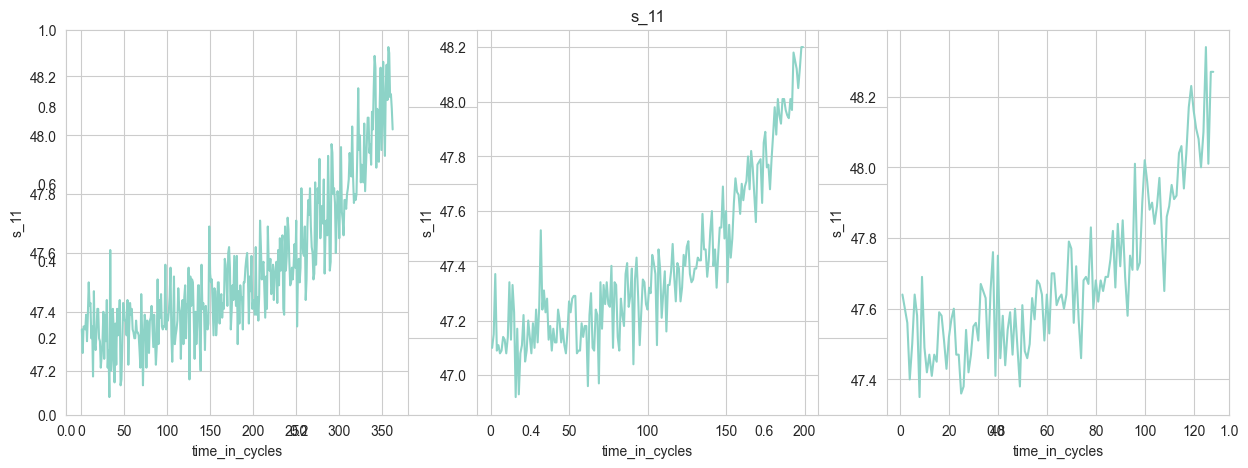

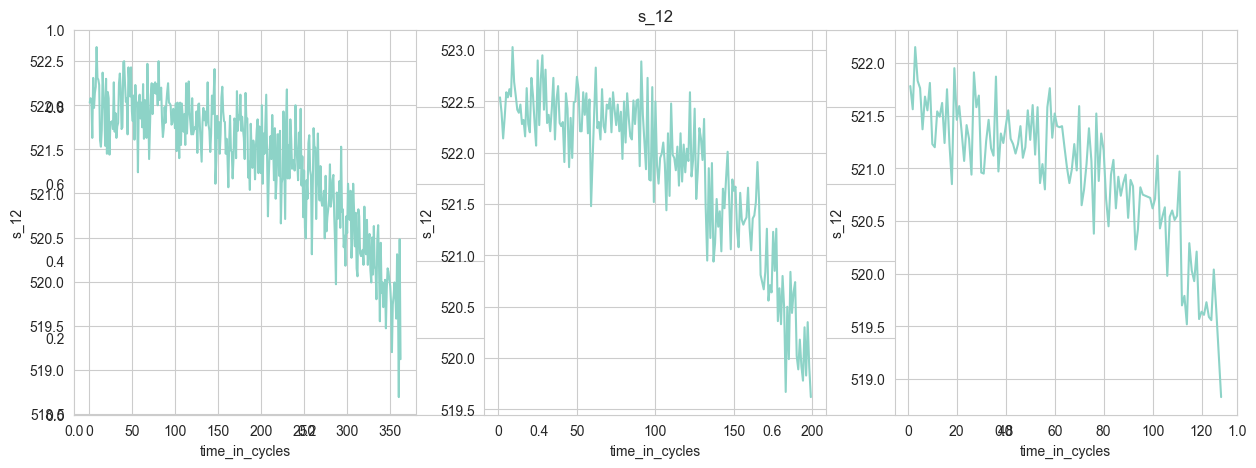

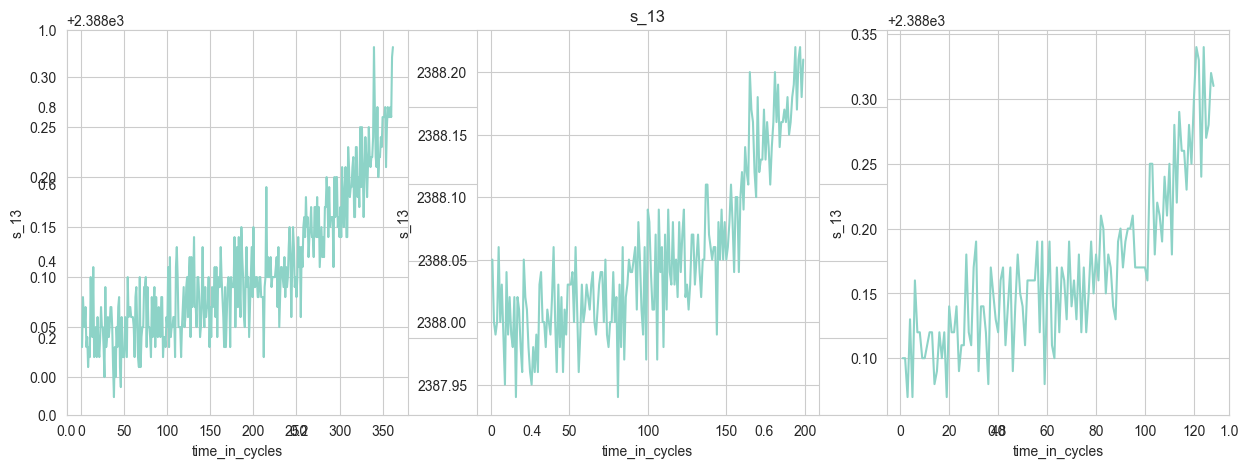

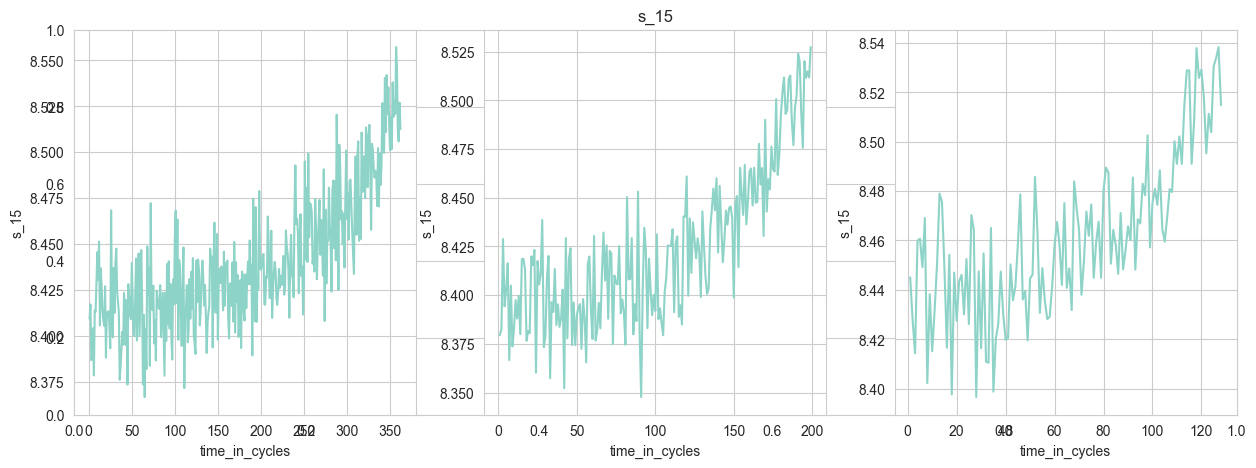

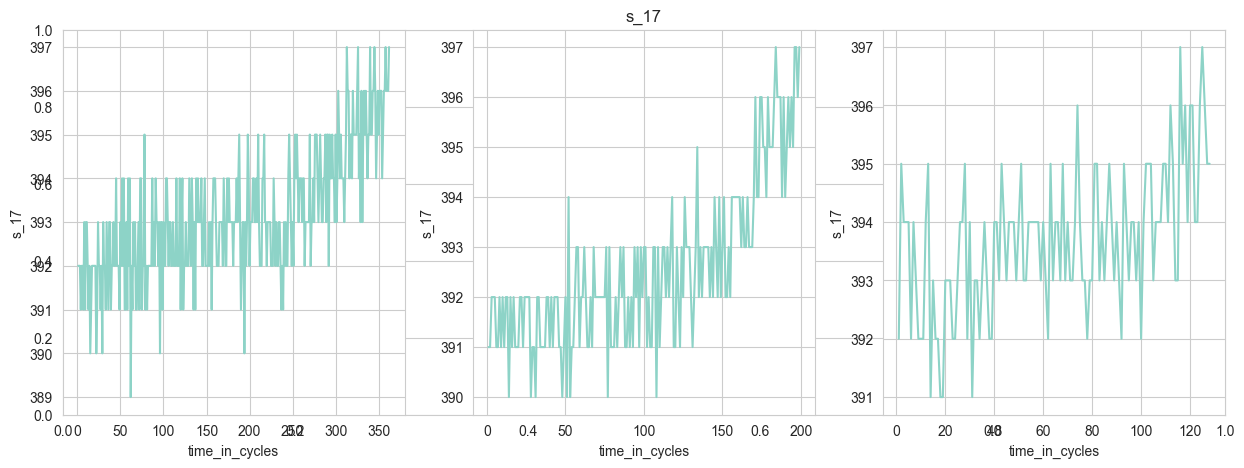

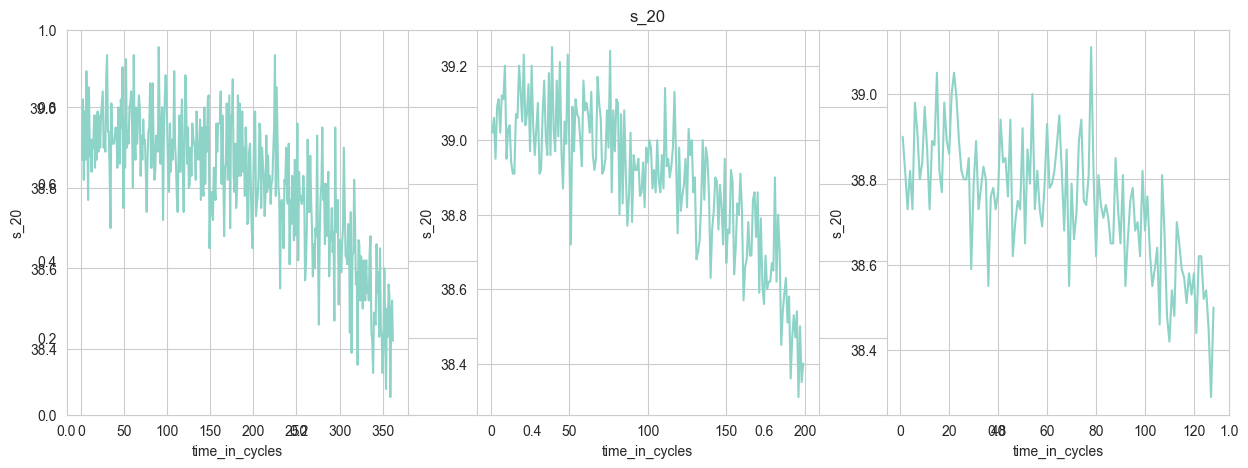

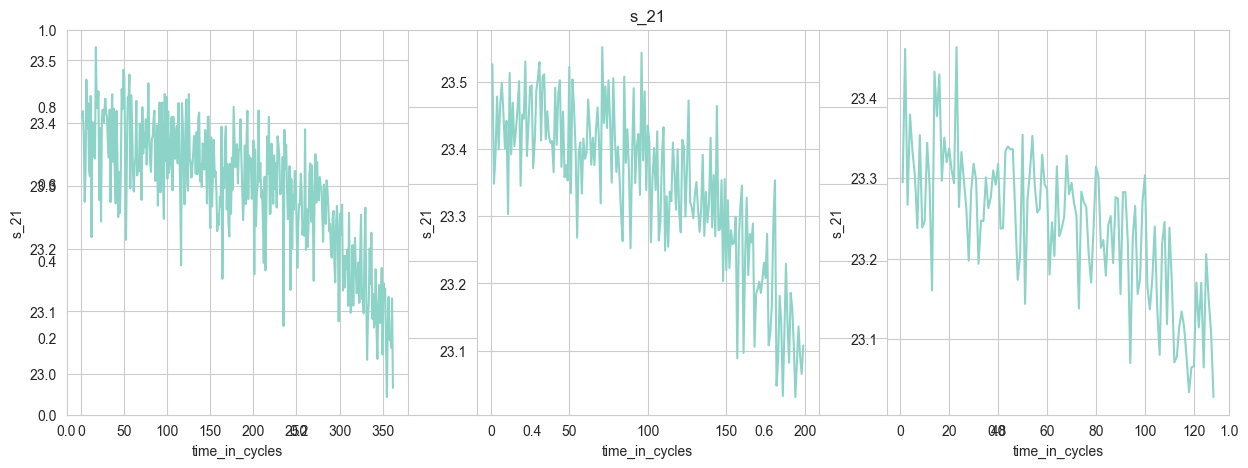

In [52]:

sns.set_style("whitegrid")

for i in range(len(machine_1_df.columns)):
    plt.figure(figsize=(15,5))
    plt.title(machine_1_df.columns[i])

    plt.subplot(1,3,1)
    sns.lineplot(x=machine_1_df["time_in_cycles"],y=machine_1_df.iloc[:,i])

    plt.subplot(1,3,2)
    sns.lineplot(x=machine_2_df["time_in_cycles"],y=machine_2_df.iloc[:,i])

    plt.subplot(1,3,3)
    sns.lineplot(x=machine_3_df["time_in_cycles"],y=machine_3_df.iloc[:,i])



In [ ]:
#I know, graphics dont make full sense without scaling all the data. Even though, we can see that sensor 7 and sensor 9 behave differently than other sensors